In [1]:
import json

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

In [3]:
dfs = {}
d_datasets = set()

for k in [
    "lcdb.workflow.sklearn.KNNWorkflow",
    "lcdb.workflow.sklearn.LibLinearWorkflow",
    "lcdb.workflow.sklearn.LibSVMWorkflow",
    "lcdb.workflow.sklearn.TreesEnsembleWorkflow",
    "lcdb.workflow.xgboost.XGBoostWorkflow"
]:
    dfs[k] = pd.read_csv(f"data/{k}.csv")
    dfs[k]["runtimes"] = dfs[k]["runtimes"].apply(lambda r: json.loads(r) if type(r) == str else None)
    d_datasets |= set(pd.unique(dfs[k]["m:openmlid"]))

In [4]:
d_datasets = sorted(d_datasets)
d_workflows = sorted(dfs.keys())

In [5]:
total_runtimes_in_s = np.zeros((len(d_workflows), len(d_datasets)))
num_datapoints = np.zeros((len(d_workflows), len(d_datasets)))
max_memory_requirements = np.zeros((len(d_workflows), len(d_datasets)))
for i, workflow in enumerate(d_workflows):
    for j, openmlid in enumerate(d_datasets):
        df_detail = dfs[workflow][dfs[workflow]["m:openmlid"] == openmlid]
        if len(df_detail) == 0:
            total_runtimes_in_s[i, j] = np.nan
            max_memory_requirements[i, j] = np.nan
            num_datapoints[i, j] = 0
        else:
            num_datapoints[i, j] = np.count_nonzero(df_detail["has_result"])
            total_runtimes_in_s[i, j] = (df_detail["m:timestamp_end"] - df_detail["m:timestamp_start"]).sum()
mean_walltime_per_config_in_s = total_runtimes_in_s / np.maximum(1, num_datapoints)

print(f"Total consumed walltime (hours) for the underlying data by workflow ({total_runtimes_in_s.sum() / 3600:.1f} in total):")
for workflow, runtimes_on_datasets in zip(d_workflows, total_runtimes_in_s):
    print(f"\t{workflow}: {np.nansum(runtimes_on_datasets) / 3600:.1f}h")

Total consumed walltime (hours) for the underlying data by workflow (3279.8 in total):
	lcdb.workflow.sklearn.KNNWorkflow: 485.1h
	lcdb.workflow.sklearn.LibLinearWorkflow: 185.3h
	lcdb.workflow.sklearn.LibSVMWorkflow: 504.0h
	lcdb.workflow.sklearn.TreesEnsembleWorkflow: 786.6h
	lcdb.workflow.xgboost.XGBoostWorkflow: 1318.9h


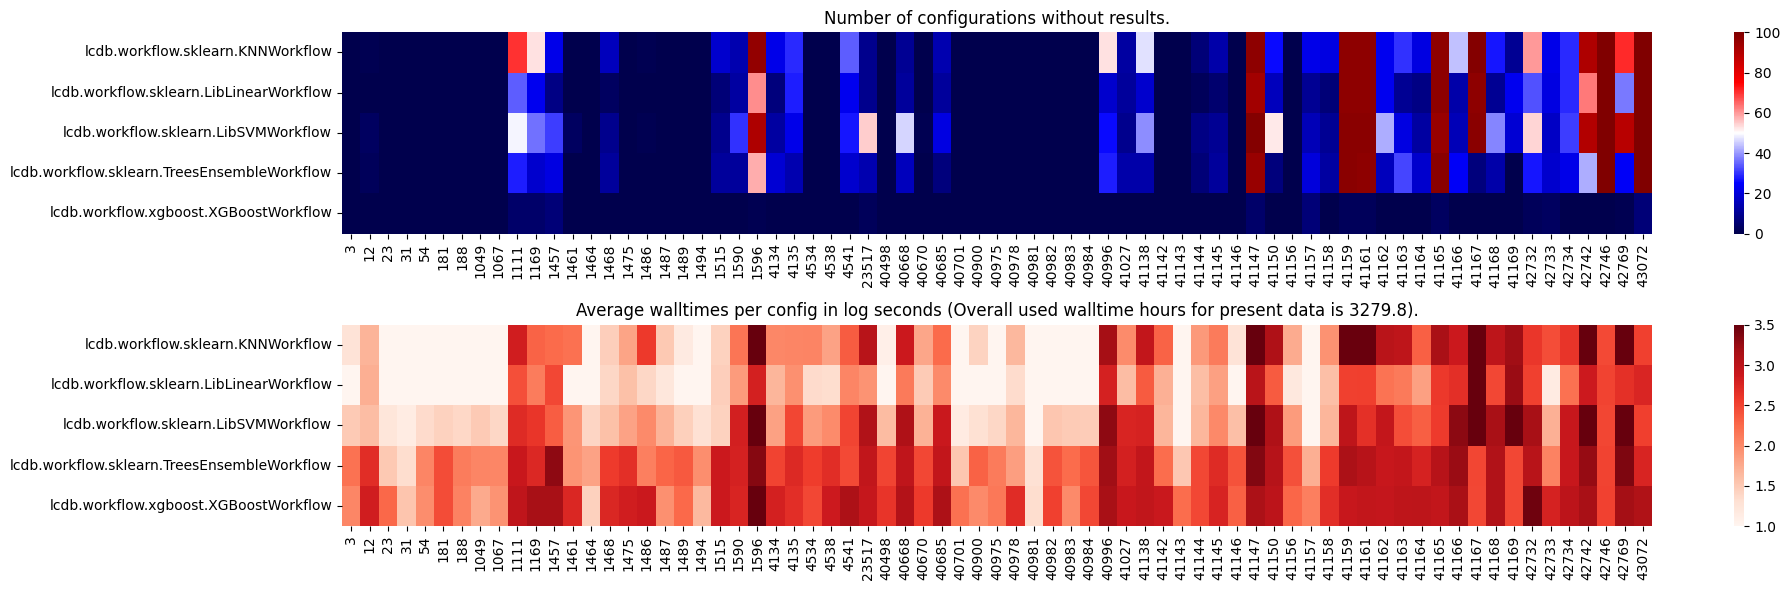

In [6]:
import matplotlib.pyplot as plt
import seaborn as sb

fig, axs = plt.subplots(2, 1, figsize=(20, 6))

# show data availability
ax = axs[0]
sb.heatmap(100 - num_datapoints, ax=ax, cmap="seismic", vmin=0, vmax=100)
ax.set_xticks(0.5 + np.arange(len(d_datasets)))
ax.set_xticklabels(d_datasets, rotation=90)
ax.set_yticklabels(d_workflows, rotation=0)
ax.set_title(f"Number of configurations without results.")

# show runtimes
ax = axs[1]
sb.heatmap(np.log10(mean_walltime_per_config_in_s), ax=ax, cmap="Reds", annot=False, fmt=".1f", vmin=1, vmax=3.5)
ax.set_xticks(0.5 + np.arange(len(d_datasets)))
ax.set_xticklabels(d_datasets, rotation=90)
ax.set_yticklabels(d_workflows, rotation=0)
ax.set_title(f"Average walltimes per config in log seconds (Overall used walltime hours for present data is {round(total_runtimes_in_s.sum() / 3600, 1)}).")


fig.tight_layout()
plt.show()

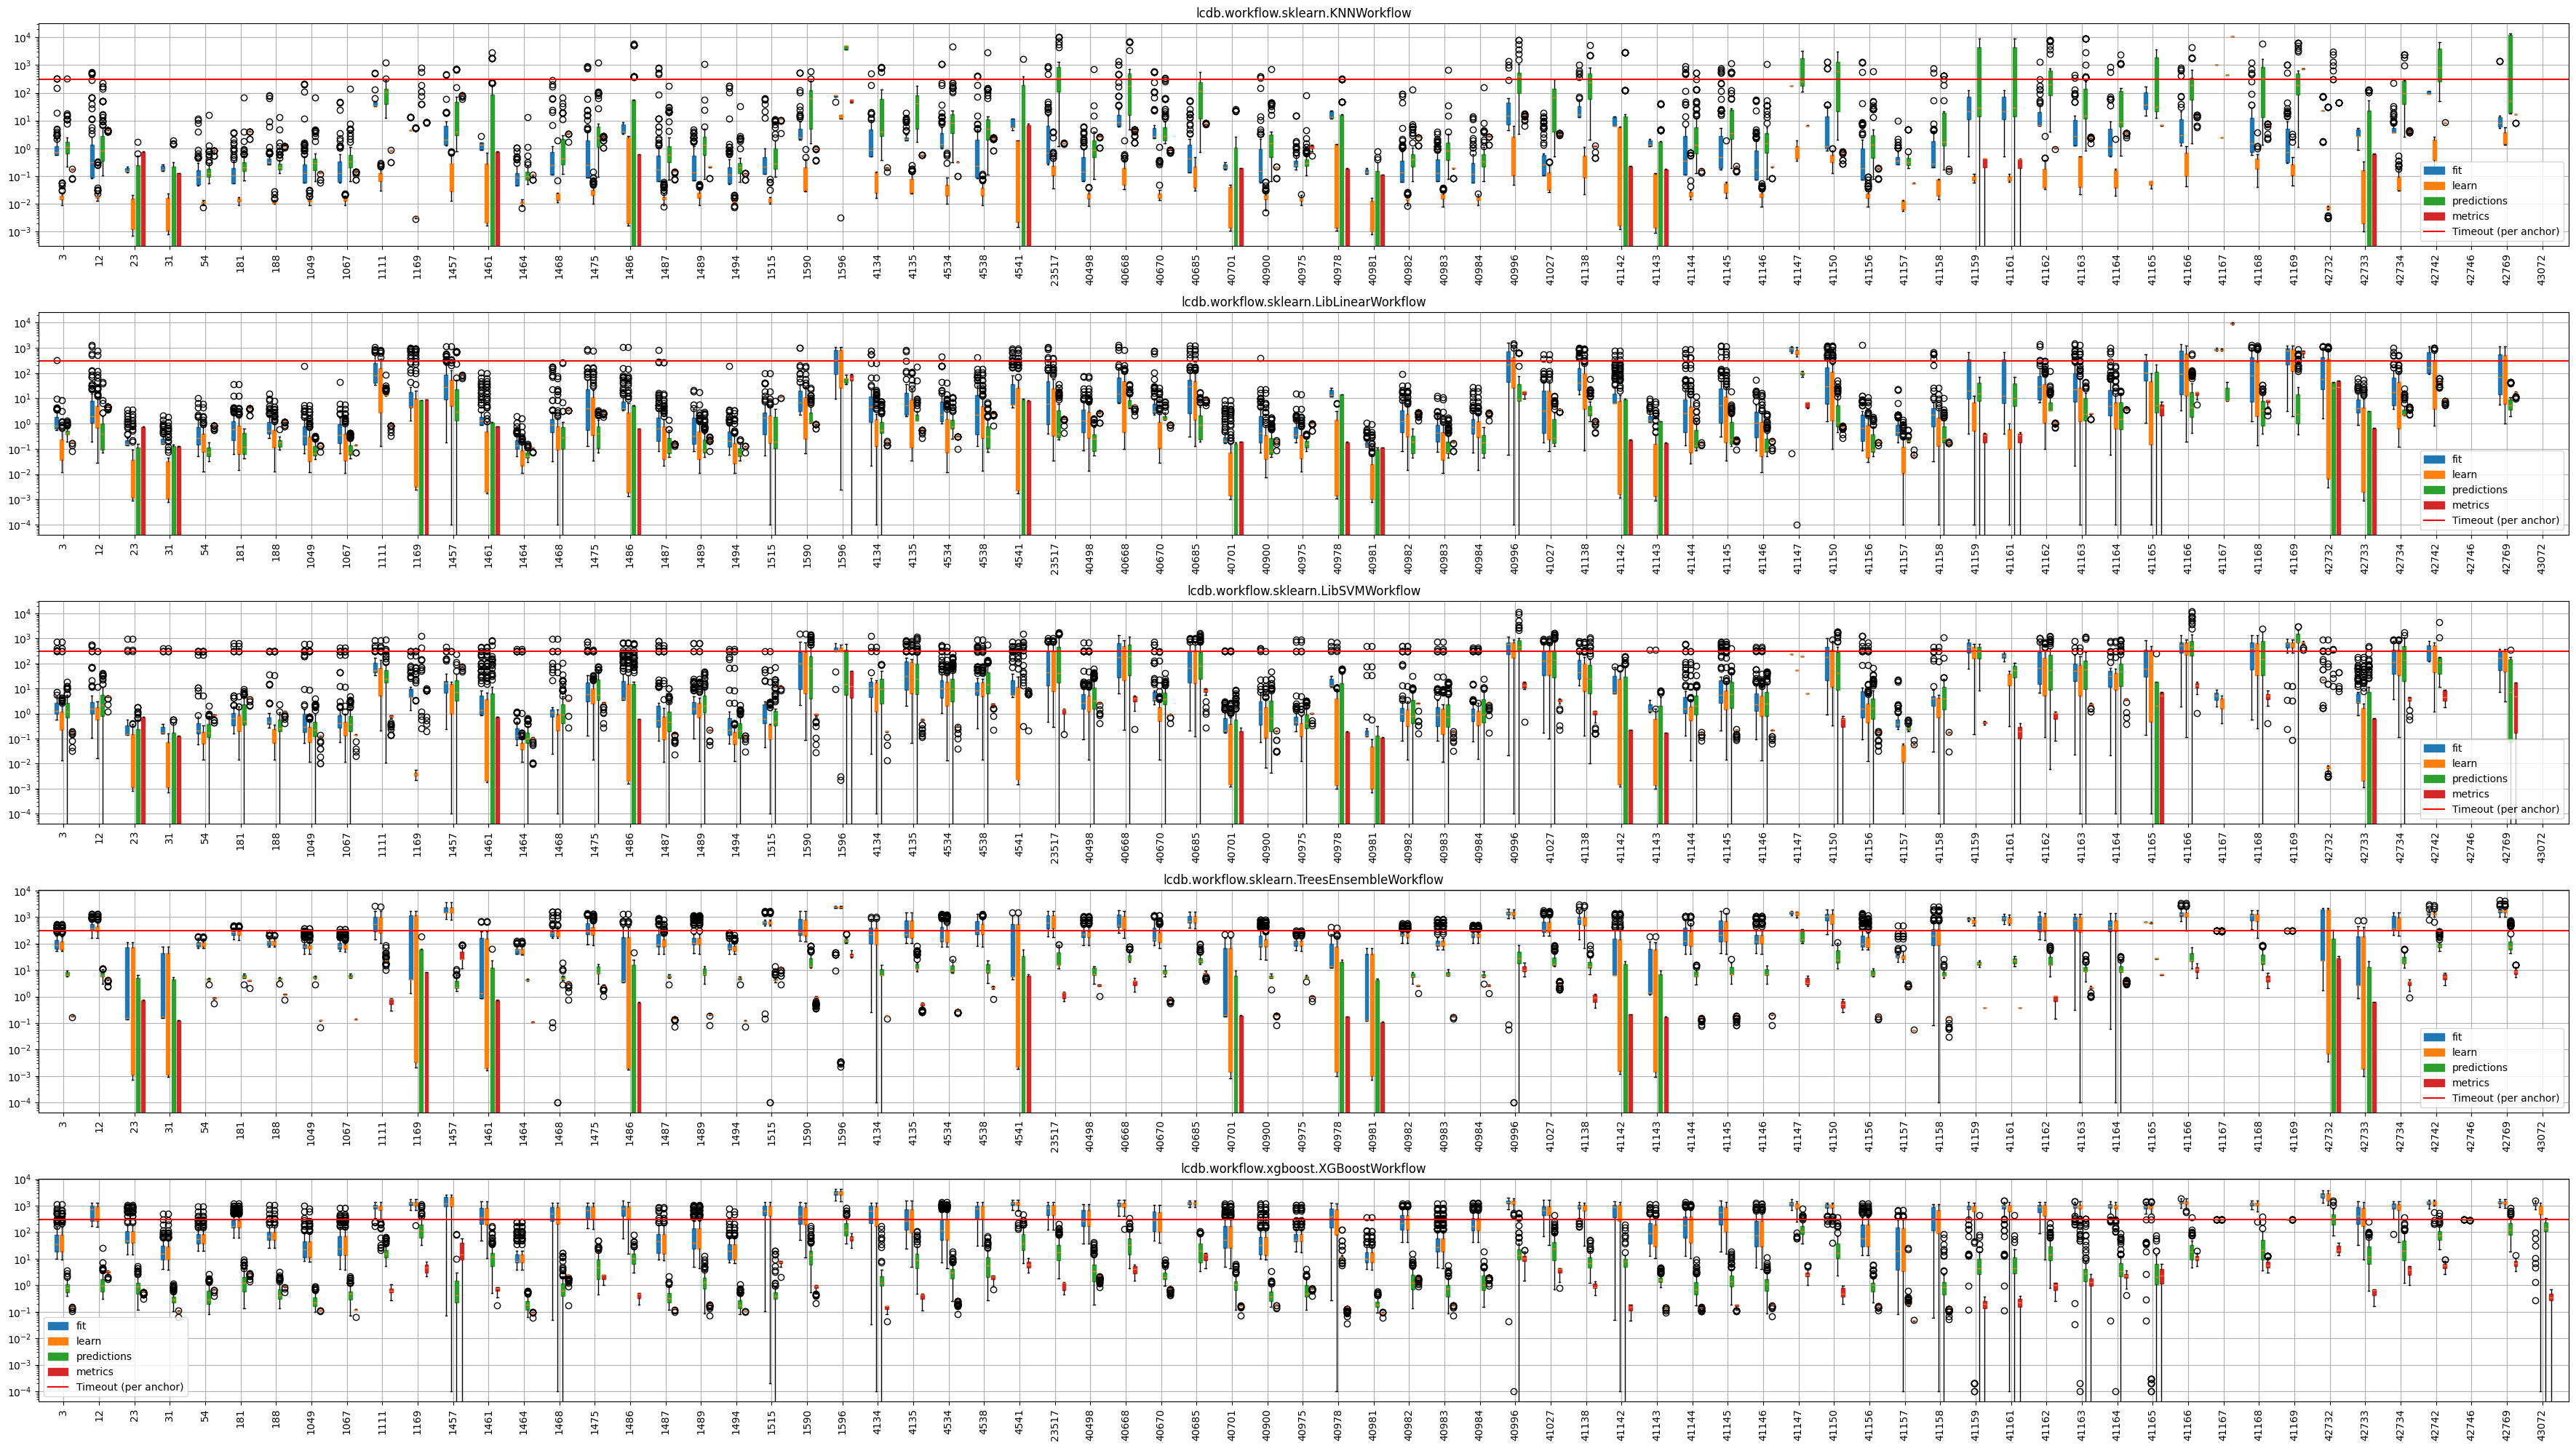

In [7]:
fig, axs = plt.subplots(len(dfs), 1, figsize=(len(d_datasets) * 0.5, 4 * len(dfs)))
if not isinstance(axs, np.ndarray):
    axs = np.array([axs])
axs = axs.reshape(-1, 1)

box_width = 0.1
for workflow, ax in zip(dfs.keys(), axs.flatten()):
    
    #tags = dfs[workflow]["runtimes"].iloc[0]["summary"].keys()
    tags = ["fit", "learn", "predictions", "metrics"]
    boxes = {
        tag: []
        for tag in tags
    }
    for openmlid in d_datasets:
        df_dataset = dfs[workflow][dfs[workflow]["m:openmlid"] == openmlid]
        runtimes_across_configs = [r["summary"] for r in df_dataset["runtimes"] if r is not None]
        for tag in tags:
            boxes[tag].append([r.get(tag, 0) for r in runtimes_across_configs])
    drawn_boxes = {}
    for i, tag in enumerate(tags):
        drawn_boxes[tag] = ax.boxplot(boxes[tag], widths=box_width, positions=box_width * 1.5 * i + np.arange(len(d_datasets)), patch_artist=True, label=tag)
    
    # set colors for times
    for i, tag in enumerate(tags):
        if tag in drawn_boxes:
            for box in drawn_boxes[tag]["boxes"]:
                box.set(facecolor=f"C{i}", edgecolor=f"C{i}")

    ax.grid()
    ax.axhline(300, color="red", label="Timeout (per anchor)")
    ax.legend()
    ax.set_yscale("log")
    ax.set_xticks(len(tags) * box_width / 2 + np.arange(len(d_datasets)))
    ax.set_xticklabels(d_datasets, rotation=90)
    ax.set_title(workflow)
fig.tight_layout()
plt.show()